In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplèot as plt
import random
import copy
import requests
import os
import math
import time
import folium
from datetime import datetime, timedelta
from google.colab import drive

!pip install polyline
import polyline

# STANDARISASI SEED & PARAMETER
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
MAX_ITER_ALL = 150 # Paksa semua 150 iterasi biar adil

drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/Data Kurir Paket Yudi Hiparni.csv'
DC_JUANDA = (-7.3817573, 112.7544115)

# --- FUNGSI CACHE OSRM ---
route_cache = {}

def get_distance_matrix(coords):
    if len(coords) <= 100:
        coord_str = ";".join([f"{c[1]},{c[0]}" for c in coords])
        url = f"http://router.project-osrm.org/table/v1/driving/{coord_str}?sources=all&destinations=all&annotations=distance"
        try:
            r = requests.get(url, timeout=30).json()
            if r.get('code') == 'Ok': return np.array(r['distances']) / 1000
        except: pass

    # Fallback Haversine jika OSRM penuh
    R = 6371.0
    mat = np.zeros((len(coords), len(coords)))
    for i in range(len(coords)):
        for j in range(len(coords)):
            if i != j:
                lat1, lon1 = math.radians(coords[i][0]), math.radians(coords[i][1])
                lat2, lon2 = math.radians(coords[j][0]), math.radians(coords[j][1])
                a = math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2
                mat[i][j] = R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return mat

def get_osrm_route_cached(p1, p2):
    cache_key = (round(p1[0],5), round(p1[1],5), round(p2[0],5), round(p2[1],5))
    if cache_key in route_cache: return route_cache[cache_key]
    url = f"http://router.project-osrm.org/route/v1/driving/{p1[1]},{p1[0]};{p2[1]},{p2[0]}?overview=full&geometries=polyline"
    try:
        r = requests.get(url, timeout=10).json()
        if r['code'] == 'Ok':
            geom = polyline.decode(r['routes'][0]['geometry'])
            route_cache[cache_key] = (geom, r['routes'][0]['distance']/1000, r['routes'][0]['duration']/3600)
            return route_cache[cache_key]
    except: pass
    route_cache[cache_key] = ([p1, p2], math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)*111, 0.05)
    return route_cache[cache_key]

# --- LOAD DATA & GROUPING ALAMAT SAMA (DEMAND AGGREGATION) ---
def load_and_group_data(path):
    try: data = pd.read_csv(path, sep=';', engine='python', encoding='utf-8-sig')
    except: data = pd.read_csv(path, sep=',', engine='python', encoding='utf-8-sig')
    data.columns = [str(c).strip() for c in data.columns]

    if 'Koordinat' in data.columns:
        data = data.dropna(subset=['Nosi', 'Koordinat']).copy()
        data['lat'] = data['Koordinat'].apply(lambda x: float(x.split(',')[0]) if pd.notna(x) else None)
        data['lon'] = data['Koordinat'].apply(lambda x: float(x.split(',')[1]) if pd.notna(x) else None)
        data['AWB'] = data['Nosi']
    elif 'Latitude' in data.columns:
        data = data.dropna(subset=['Latitude', 'Longitude']).copy()
        data['lat'] = data['Latitude'].apply(lambda x: float(str(x).replace(',','.')))
        data['lon'] = data['Longitude'].apply(lambda x: float(str(x).replace(',','.')))
        if 'AWB' not in data.columns: data['AWB'] = data.index

    # Ambil 141 paket pertama
    data = data.dropna(subset=['lat', 'lon']).reset_index(drop=True).head(141)

    # 💡 1. PENGELOMPOKAN TITIK ALAMAT YANG SAMA (Grouping)
    df_grouped = data.groupby(['lat', 'lon']).agg({'AWB': lambda x: list(x)}).reset_index()
    df_grouped['jumlah_paket'] = df_grouped['AWB'].apply(len)
    df_grouped['coords'] = list(zip(df_grouped['lat'], df_grouped['lon']))

    # 💡 2. SPATIAL SORTING (Urutkan dari Barat ke Timur agar wilayah rapi)
    df_grouped = df_grouped.sort_values(by='lon').reset_index(drop=True)
    return df_grouped

# Eksekusi fungsi grouping
df_grouped = load_and_group_data(file_path)

# 💡 3. MEMBAGI TRIP DENGAN BATAS KAPASITAS 50 PAKET (Bukan 50 Titik)
trip_ids = []
current_trip = 0
current_load = 0

for idx, row in df_grouped.iterrows():
    if current_load + row['jumlah_paket'] > 50:
        current_trip += 1
        current_load = 0
    trip_ids.append(current_trip)
    current_load += row['jumlah_paket']

df_grouped['trip_id'] = trip_ids

print(f"✅ Data Siap: {df_grouped['jumlah_paket'].sum()} Paket telah dilebur menjadi {len(df_grouped)} Titik Alamat Unik.")
for t in df_grouped['trip_id'].unique():
    n_paket = df_grouped[df_grouped['trip_id']==t]['jumlah_paket'].sum()
    n_titik = len(df_grouped[df_grouped['trip_id']==t])
    print(f"   - Trip {t+1}: {n_paket} paket di {n_titik} titik antar.")

# --- DEFINISI 4 ALGORITMA (SUDAH DI-TUNING OLEH OPTUNA) ---
def calc_dist(route, matrix):
    return matrix[0][route[0]] + sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1)) + matrix[route[-1]][0]

def optimize_SA(num_p, matrix):
    curr_r = list(range(1, num_p + 1)); random.shuffle(curr_r)
    curr_d = calc_dist(curr_r, matrix)
    best_r, best_d, history = copy.deepcopy(curr_r), curr_d, []

    # 🔥 Parameter Hasil Optuna
    cooling = 0.9176
    temp = 100.0

    for _ in range(MAX_ITER_ALL):
        new_r = copy.deepcopy(curr_r); i, j = random.sample(range(num_p), 2)
        new_r[i], new_r[j] = new_r[j], new_r[i]
        new_d = calc_dist(new_r, matrix)
        if new_d < curr_d or random.random() < math.exp((curr_d - new_d) / temp):
            curr_r, curr_d = new_r, new_d
            if curr_d < best_d: best_r, best_d = copy.deepcopy(curr_r), curr_d
        history.append(best_d); temp *= cooling
    return best_r, best_d, history

def optimize_ACO(num_p, matrix):
    # 🔥 Parameter Hasil Optuna (Alpha, Beta, Evaporation)
    n_ants, alpha, beta, evap = 25, 0.67, 2.09, 0.23

    pheromone = np.ones((num_p+1, num_p+1))
    best_r, best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        for _ in range(n_ants):
            unvisited = list(range(1, num_p+1)); curr, route, d_route = 0, [], 0
            while unvisited:
                probs = [(pheromone[curr][n]**alpha) * ((1.0/(matrix[curr][n]+0.001))**beta) for n in unvisited]
                probs = np.array(probs) / sum(probs)
                next_node = np.random.choice(unvisited, p=probs)
                route.append(next_node); d_route += matrix[curr][next_node]
                unvisited.remove(next_node); curr = next_node
            d_route += matrix[curr][0]
            if d_route < best_d: best_r, best_d = route, d_route
            curr_n = 0
            for node in route: pheromone[curr_n][node] += 1.0 / d_route; curr_n = node
        pheromone *= (1 - evap); history.append(best_d)
    return best_r, best_d, history

def optimize_GA(num_p, matrix):
    # 🔥 Parameter Hasil Optuna (Pop Size & Mut_rate)
    pop_size = 55
    mut_rate = 0.32

    pop = [random.sample(range(1, num_p + 1), num_p) for _ in range(pop_size)]
    best_r, best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        pop = sorted(pop, key=lambda x: calc_dist(x, matrix))
        if calc_dist(pop[0], matrix) < best_d: best_r, best_d = copy.deepcopy(pop[0]), calc_dist(pop[0], matrix)
        history.append(best_d)
        next_gen = pop[:10]
        while len(next_gen) < pop_size:
            p1, p2 = random.sample(pop[:20], 2); pt = random.randint(1, num_p-1)
            child = p1[:pt] + [g for g in p2 if g not in p1[:pt]]
            if random.random() < mut_rate:
                i, j = random.sample(range(num_p), 2); child[i], child[j] = child[j], child[i]
            next_gen.append(child)
        pop = next_gen
    return best_r, best_d, history

def optimize_LBA(num_p, matrix):
    # 🔥 Parameter Hasil Optuna (Pop Size & Max Loop Local Search)
    pop_size = 69
    max_loop = 20

    pop = [random.sample(range(1, num_p + 1), num_p) for _ in range(pop_size)]
    g_best_r, g_best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        fitnesses = [calc_dist(ind, matrix) for ind in pop]
        c_best_idx = np.argmin(fitnesses)
        c_best_r, c_best_d = copy.deepcopy(pop[c_best_idx]), fitnesses[c_best_idx]
        if c_best_d < g_best_d: g_best_r, g_best_d = copy.deepcopy(c_best_r), c_best_d
        else:
            ls_r, ls_d = copy.deepcopy(g_best_r), g_best_d
            for _ in range(max_loop):
                temp_r = copy.deepcopy(ls_r); i, j = random.sample(range(num_p), 2)
                temp_r[i], temp_r[j] = temp_r[j], temp_r[i]
                temp_d = calc_dist(temp_r, matrix)
                if temp_d < ls_d: ls_r, ls_d = temp_r, temp_d
            if ls_d < g_best_d: g_best_r, g_best_d = copy.deepcopy(ls_r), ls_d
        history.append(g_best_d)
        new_pop = [copy.deepcopy(g_best_r)]
        while len(new_pop) < pop_size:
            S = random.choice(pop[:20])
            if random.random() < 0.9:
                idx1, idx2 = sorted(random.sample(range(num_p), 2)); a = random.randint(1, 5); cand = copy.deepcopy(S)
                if a == 1 and idx2 < num_p - 1: cand[idx1:idx1+2], cand[idx2:idx2+2] = cand[idx2:idx2+2], cand[idx1:idx1+2]
                elif a == 2: cand[idx1:idx2+1] = reversed(cand[idx1:idx2+1])
                elif a == 3: cand[idx1], cand[idx2] = cand[idx2], cand[idx1]
                elif a == 4: val = cand.pop(idx1); cand.insert(idx2, val)
                elif a == 5: sub = cand[idx1:idx2+1]; random.shuffle(sub); cand[idx1:idx2+1] = sub
            else: cand = copy.deepcopy(S); random.shuffle(cand)
            new_pop.append(cand)
        pop = new_pop
    return g_best_r, g_best_d, history

Mounted at /content/drive
✅ Data Siap: 141 Paket telah dilebur menjadi 90 Titik Alamat Unik.
   - Trip 1: 50 paket di 30 titik antar.
   - Trip 2: 49 paket di 30 titik antar.
   - Trip 3: 42 paket di 30 titik antar.


In [ ]:
komparasi_results = []
all_routes_map = {'SA': [], 'ACO': [], 'GA': [], 'LBA': []}
history_plot = {'SA': [], 'ACO': [], 'GA': [], 'LBA': []}

print("🏁 MEMULAI EVALUASI KOMPARASI ALGORITMA (ETS) 🏁\n")

for i in range(len(df_grouped['trip_id'].unique())):
    df_segment = df_grouped[df_grouped['trip_id'] == i].copy()
    coords_trip = [DC_JUANDA] + df_segment['coords'].tolist()
    matrix = get_distance_matrix(coords_trip)
    num_p = len(df_segment)
    total_paket_trip = df_segment['jumlah_paket'].sum()
    print(f"📦 Memproses Trip {i+1} ({num_p} Titik Antar, {total_paket_trip} Paket)...")

    t0 = time.time(); best_r_sa, d_sa, h_sa = optimize_SA(num_p, matrix); t_sa = time.time() - t0
    t0 = time.time(); best_r_aco, d_aco, h_aco = optimize_ACO(num_p, matrix); t_aco = time.time() - t0
    t0 = time.time(); best_r_ga, d_ga, h_ga = optimize_GA(num_p, matrix); t_ga = time.time() - t0
    t0 = time.time(); best_r_lba, d_lba, h_lba = optimize_LBA(num_p, matrix); t_lba = time.time() - t0

    if i == 0:
        history_plot['SA'], history_plot['ACO'] = h_sa, h_aco
        history_plot['GA'], history_plot['LBA'] = h_ga, h_lba

    def process_route_data(algo_name, best_idx):
        r_coords = [DC_JUANDA] + [df_segment.iloc[idx-1]['coords'] for idx in best_idx] + [DC_JUANDA]
        full_geom = []; durasi_jalan_sec = 0

        for j in range(len(r_coords)-1):
            geom, _, t_h = get_osrm_route_cached(r_coords[j], r_coords[j+1])
            if geom: full_geom.extend(geom)
            durasi_jalan_sec += (t_h * 3600)

        # 💡 REVISI: Murni Waktu Berkendara OSRM (Tanpa Waktu Ketok Pintu/Service Time)
        total_durasi_sec = durasi_jalan_sec

        # Simpan paket berdasarkan titik antar yang baru
        paket_urutan = [(idx_seq+1, r_coords[idx_seq+1], df_segment.iloc[best_idx[idx_seq]-1]) for idx_seq in range(num_p)]
        all_routes_map[algo_name].append({'geom': full_geom, 'paket': paket_urutan})
        return total_durasi_sec

    sec_sa = process_route_data('SA', best_r_sa)
    sec_aco = process_route_data('ACO', best_r_aco)
    sec_ga = process_route_data('GA', best_r_ga)
    sec_lba = process_route_data('LBA', best_r_lba)

    komparasi_results.append({
        'Trip': f'Trip {i+1}',
        'Dist_SA': d_sa, 'Time_SA': t_sa, 'OSRM_SA(jam)': sec_sa/3600,
        'Dist_ACO': d_aco, 'Time_ACO': t_aco, 'OSRM_ACO(jam)': sec_aco/3600,
        'Dist_GA': d_ga, 'Time_GA': t_ga, 'OSRM_GA(jam)': sec_ga/3600,
        'Dist_LBA': d_lba, 'Time_LBA': t_lba, 'OSRM_LBA(jam)': sec_lba/3600
    })

df_hasil = pd.DataFrame(komparasi_results)
df_hasil.loc['TOTAL'] = df_hasil.sum(numeric_only=True)
df_hasil.at['TOTAL', 'Trip'] = 'TOTAL KESELURUHAN'
display(df_hasil)

🏁 MEMULAI EVALUASI KOMPARASI ALGORITMA (UAS - VRPTW + SLA) 🏁

📦 Memproses Trip 1 (30 Titik Antar, 50 Paket, 5 Titik PE)...
📦 Memproses Trip 2 (30 Titik Antar, 49 Paket, 7 Titik PE)...
📦 Memproses Trip 3 (30 Titik Antar, 42 Paket, 8 Titik PE)...

📊 HASIL KOMPARASI TOTAL (JARAK, DURASI TOTAL, PELANGGARAN SLA, WAKTU KOMPUTASI) 📊


,Trip,Dist_SA(km),Dur_SA(jam),Viol_SA,Time_SA(s),Dist_ACO(km),Dur_ACO(jam),Viol_ACO,Time_ACO(s),Dist_GA(km),Dur_GA(jam),Viol_GA,Time_GA(s),Dist_LBA(km),Dur_LBA(jam),Viol_LBA,Time_LBA(s)
0,Trip 1,45.9372,3.181611,0.0,0.022293,21.1680,2.471361,0.0,12.369192,30.5369,2.765778,0.0,0.262077,23.9803,2.601833,0.0,0.491846
1,Trip 2,58.3077,3.586722,0.0,0.011264,33.3657,2.834139,0.0,6.745766,40.5807,3.069417,0.0,0.258928,36.0341,2.918111,0.0,0.517602
2,Trip 3,50.2697,3.176056,0.0,0.005984,28.4120,2.510333,0.0,6.239905,36.7943,2.716528,0.0,0.260562,35.9061,2.715944,0.0,0.612209
TOTAL,TOTAL KESELURUHAN,154.5146,9.944389,0.0,0.039542,82.9457,7.815833,0.0,25.354863,107.9119,8.551722,0.0,0.781567,95.9205,8.235889,0.0,1.621657


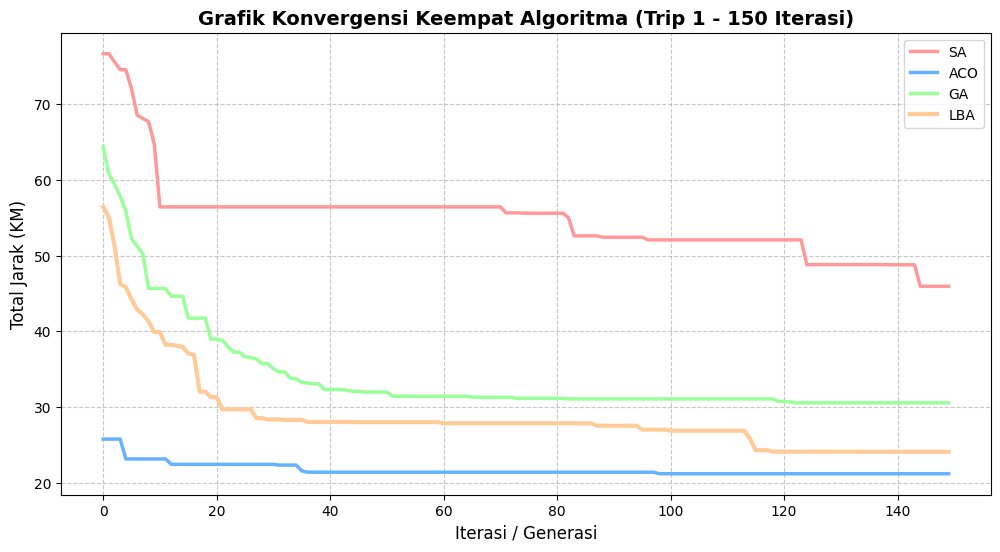

/tmp/ipykernel_14682/4193514500.py:34: UserWarning: color argument of Icon should be one of: {'purple', 'lightblue', 'blue', 'green', 'darkpurple', 'darkblue', 'lightred', 'lightgreen', 'darkred', 'white', 'pink', 'gray', 'orange', 'darkgreen', 'black', 'cadetblue', 'lightgray', 'beige', 'red'}.
  folium.Marker(location=coords, icon=folium.Icon(color='info', icon='info-sign')).add_to(layers[algo_name])


In [ ]:
# --- 1. PLOT GRAFIK KONVERGENSI ---
plt.figure(figsize=(12, 6))
plt.plot(history_plot['SA'], label='SA', color='#FF9999', linewidth=2.5)
plt.plot(history_plot['ACO'], label='ACO', color='#66B2FF', linewidth=2.5)
plt.plot(history_plot['GA'], label='GA', color='#99FF99', linewidth=2.5)
plt.plot(history_plot['LBA'], label='LBA', color='#FFCC99', linewidth=3)
plt.title('Grafik Konvergensi Keempat Algoritma (Trip 1 - 150 Iterasi)', fontweight='bold', fontsize=14)
plt.xlabel('Iterasi / Generasi', fontsize=12); plt.ylabel('Total Jarak (KM)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7); plt.legend()
plt.show()

# --- 2. MAP RUTE INTERAKTIF ---
m = folium.Map(location=[DC_JUANDA[0], DC_JUANDA[1]], zoom_start=13, tiles='CartoDB positron')
folium.Marker(location=DC_JUANDA, popup='<b>DEPOT DC JUANDA</b>', icon=folium.Icon(color='black', icon='home')).add_to(m)

layers = {
    'SA': folium.FeatureGroup(name='Rute & Urutan SA', show=False),
    'ACO': folium.FeatureGroup(name='Rute & Urutan ACO', show=False),
    'GA': folium.FeatureGroup(name='Rute & Urutan GA', show=False),
    'LBA': folium.FeatureGroup(name='Rute & Urutan LBA', show=True)
}

trip_colors = ['red', 'green', 'blue']

for algo_name in ['SA', 'ACO', 'GA', 'LBA']:
    for trip_idx, trip_data in enumerate(all_routes_map[algo_name]):
        color = trip_colors[trip_idx]
        folium.PolyLine(locations=trip_data['geom'], color=color, weight=4, opacity=0.7).add_to(layers[algo_name])

        for urutan, coords, data_titik in trip_data['paket']:
            resi_list = ", ".join([str(x) for x in data_titik['AWB']])
            jml_paket = data_titik['jumlah_paket']

            folium.Marker(location=coords, icon=folium.Icon(color='info', icon='info-sign')).add_to(layers[algo_name])
            html_num = f'''<div style="font-size: 8pt; color: white; font-weight: bold; background-color: {color};
                           border-radius: 50%; width: 22px; height: 22px; line-height: 22px;
                           text-align: center; border: 2px solid white; box-shadow: 0px 0px 5px rgba(0,0,0,0.5);">
                           {urutan}</div>'''
            folium.map.Marker(location=coords, icon=folium.DivIcon(icon_size=(22, 22), icon_anchor=(11, -12), html=html_num)).add_to(layers[algo_name])

            popup_html = f"<b>{algo_name} - Trip {trip_idx+1}</b><br>Stop ke: {urutan}<br>Total Paket di Titik Ini: {jml_paket}<br>Resi: {resi_list}"
            folium.Marker(location=coords, icon=folium.Icon(opacity=0), popup=folium.Popup(popup_html, max_width=250)).add_to(layers[algo_name])

for layer in layers.values(): layer.add_to(m)
folium.LayerControl(position='topright', collapsed=False).add_to(m)

m.save("Peta_Evaluasi_ETS.html")
display(m)

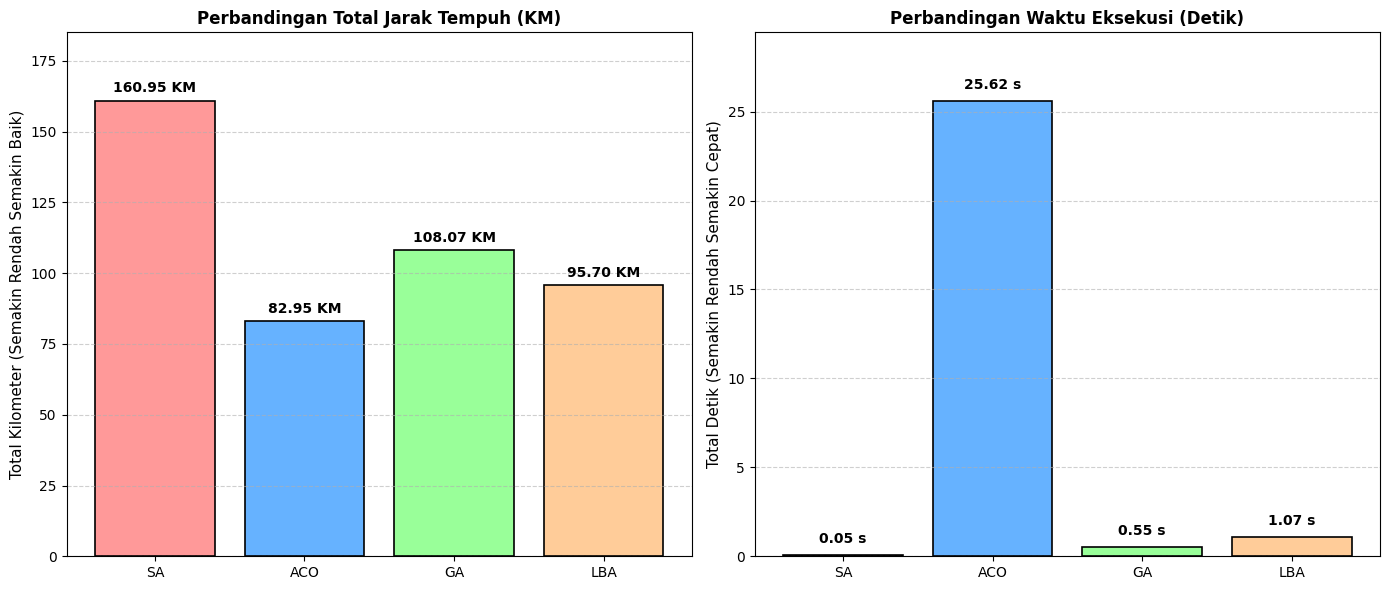

In [ ]:
import matplotlib.pyplot as plt

algoritma = ['SA', 'ACO', 'GA', 'LBA']

jarak_total = [
    df_hasil.loc['TOTAL', 'Dist_SA'],
    df_hasil.loc['TOTAL', 'Dist_ACO'],
    df_hasil.loc['TOTAL', 'Dist_GA'],
    df_hasil.loc['TOTAL', 'Dist_LBA']
]

waktu_total = [
    df_hasil.loc['TOTAL', 'Time_SA'],
    df_hasil.loc['TOTAL', 'Time_ACO'],
    df_hasil.loc['TOTAL', 'Time_GA'],
    df_hasil.loc['TOTAL', 'Time_LBA']
]

warna = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Jarak Tempuh ---
bars_jarak = axes[0].bar(algoritma, jarak_total, color=warna, edgecolor='black', linewidth=1.2)
axes[0].set_title('Perbandingan Total Jarak Tempuh (KM)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Total Kilometer (Semakin Rendah Semakin Baik)', fontsize=11)
axes[0].set_ylim(0, max(jarak_total) * 1.15)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars_jarak:
    tinggi = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., tinggi + 2,
                 f'{tinggi:.2f} KM', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Waktu Eksekusi ---
bars_waktu = axes[1].bar(algoritma, waktu_total, color=warna, edgecolor='black', linewidth=1.2)
axes[1].set_title('Perbandingan Waktu Eksekusi (Detik)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Total Detik (Semakin Rendah Semakin Cepat)', fontsize=11)
axes[1].set_ylim(0, max(waktu_total) * 1.15)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars_waktu:
    tinggi = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., tinggi + 0.5,
                 f'{tinggi:.2f} s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Membaca ulang data asli untuk mendapatkan urutan historis
try:
    data_asli = pd.read_csv(file_path, sep=';', engine='python', encoding='utf-8-sig')
except:
    data_asli = pd.read_csv(file_path, sep=',', engine='python', encoding='utf-8-sig')

data_asli.columns = [str(c).strip() for c in data_asli.columns]

if 'Koordinat' in data_asli.columns:
    data_asli = data_asli.dropna(subset=['Nosi', 'Koordinat']).copy()
    data_asli['lat'] = data_asli['Koordinat'].apply(lambda x: float(x.split(',')[0]) if pd.notna(x) else None)
    data_asli['lon'] = data_asli['Koordinat'].apply(lambda x: float(x.split(',')[1]) if pd.notna(x) else None)
elif 'Latitude' in data_asli.columns:
    data_asli = data_asli.dropna(subset=['Latitude', 'Longitude']).copy()
    data_asli['lat'] = data_asli['Latitude'].apply(lambda x: float(str(x).replace(',','.')))
    data_asli['lon'] = data_asli['Longitude'].apply(lambda x: float(str(x).replace(',','.')))

data_asli = data_asli.dropna(subset=['lat', 'lon']).reset_index(drop=True).head(141)

# 2. Ekstrak koordinat berurutan sesuai history asli (tanpa sorting spasial)
rute_riil_coords = []
for _, row in data_asli.iterrows():
    coord = (row['lat'], row['lon'])
    if not rute_riil_coords or rute_riil_coords[-1] != coord:
        rute_riil_coords.append(coord)

rute_riil_lengkap = [DC_JUANDA] + rute_riil_coords + [DC_JUANDA]

# 3. Menghitung Jarak dan Durasi menggunakan OSRM Cache
jarak_baseline = 0
durasi_baseline_sec = 0

print("⏳ Menghitung Jarak Riil (Baseline Aktual) berdasarkan history CSV...")
for j in range(len(rute_riil_lengkap)-1):
    _, d_km, t_h = get_osrm_route_cached(rute_riil_lengkap[j], rute_riil_lengkap[j+1])
    jarak_baseline += d_km
    durasi_baseline_sec += (t_h * 3600)

durasi_baseline_jam = durasi_baseline_sec / 3600
bbm_liter = jarak_baseline / 40

print("==================================================")
print(f"✅ Jarak Baseline Riil    : {jarak_baseline:.2f} KM")
print(f"✅ Durasi Baseline OSRM   : {durasi_baseline_jam:.2f} Jam")
print(f"✅ Estimasi Konsumsi BBM  : {bbm_liter:.2f} Liter")
print("==================================================")

⏳ Menghitung Jarak Riil (Baseline Aktual) berdasarkan history CSV...
✅ Jarak Baseline Riil    : 138.65 KM
✅ Durasi Baseline OSRM   : 4.52 Jam
✅ Estimasi Konsumsi BBM  : 3.47 Liter


⏳ Menjalankan SA dengan 1200 iterasi untuk SELURUH TRIP...
✅ Trip 1 Selesai: 34.85 KM
✅ Trip 2 Selesai: 47.22 KM
✅ Trip 3 Selesai: 39.22 KM
📍 Baseline Riil Kurir     : 138.65 KM
📍 SA (Batas 150 Iterasi)  : 160.85 KM
📍 SA (Optimal 1200 Iterasi): 121.29 KM


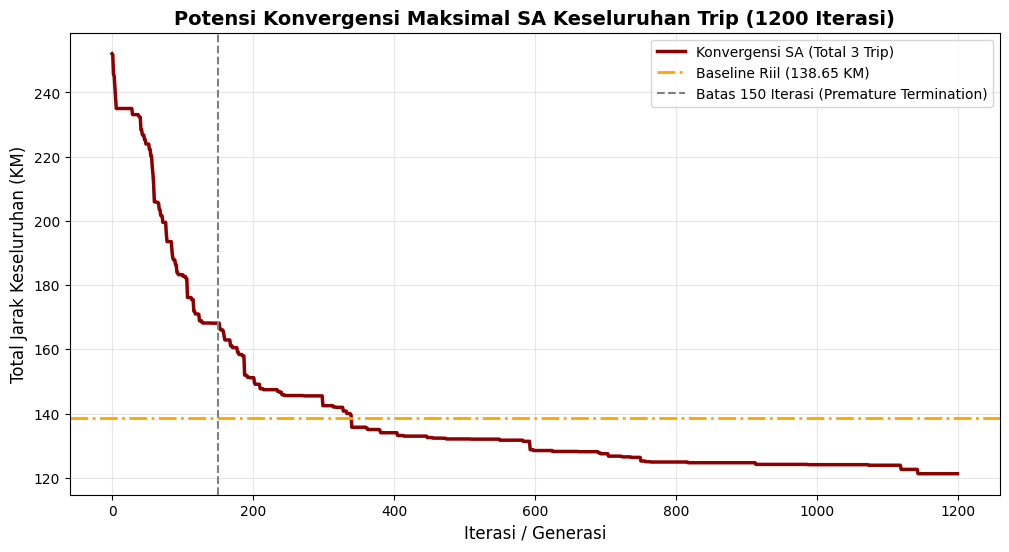

In [ ]:
# --- STUDI KASUS EKSTENSIF: POTENSI MAKSIMAL SIMULATED ANNEALING (ALL TRIPS) ---
MAX_ITER_EXTREME = 1200
print(f"⏳ Menjalankan SA dengan {MAX_ITER_EXTREME} iterasi untuk SELURUH TRIP...")

total_dist_1200 = 0
histories_1200 = []

# Modifikasi fungsi SA agar menerima iterasi custom (jika belum ada)
def optimize_SA_custom(num_p, matrix, max_iter):
    curr_r = list(range(1, num_p + 1)); random.shuffle(curr_r)
    curr_d = calc_dist(curr_r, matrix)
    best_r, best_d, history = copy.deepcopy(curr_r), curr_d, []
    cooling, temp = 0.9176, 100.0
    for _ in range(max_iter):
        new_r = copy.deepcopy(curr_r); i, j = random.sample(range(num_p), 2)
        new_r[i], new_r[j] = new_r[j], new_r[i]
        new_d = calc_dist(new_r, matrix)
        if new_d < curr_d or random.random() < math.exp((curr_d - new_d) / temp):
            curr_r, curr_d = new_r, new_d
            if curr_d < best_d: best_r, best_d = copy.deepcopy(curr_r), curr_d
        history.append(best_d); temp *= cooling
    return best_d, history

# Looping untuk ke-3 trip
for i in range(len(df_grouped['trip_id'].unique())):
    df_segment = df_grouped[df_grouped['trip_id'] == i].copy()
    coords_trip = [DC_JUANDA] + df_segment['coords'].tolist()
    matrix = get_distance_matrix(coords_trip)
    num_p = len(df_segment)

    best_d, hist = optimize_SA_custom(num_p, matrix, MAX_ITER_EXTREME)
    total_dist_1200 += best_d
    histories_1200.append(hist)
    print(f"✅ Trip {i+1} Selesai: {best_d:.2f} KM")

# Menjumlahkan array history dari ketiga trip pada setiap iterasinya
hist_total_1200 = [sum(x) for x in zip(*histories_1200)]

# Ambil total jarak SA di 150 iterasi dari tabel df_hasil sebelumnya
total_sa_150 = df_hasil.loc['TOTAL', 'Dist_SA']

print("==================================================")
print(f"📍 Baseline Riil Kurir     : 138.65 KM")
print(f"📍 SA (Batas 150 Iterasi)  : {total_sa_150:.2f} KM")
print(f"📍 SA (Optimal 1200 Iterasi): {total_dist_1200:.2f} KM")
print("==================================================")

# Plotting untuk Laporan
plt.figure(figsize=(12, 6))
plt.plot(hist_total_1200, label='Konvergensi SA (Total 3 Trip)', color='darkred', linewidth=2.5)

# Garis referensi
plt.axhline(y=138.65, color='orange', linestyle='-.', linewidth=2, label='Baseline Riil (138.65 KM)')
plt.axvline(x=150, color='gray', linestyle='--', label='Batas 150 Iterasi (Premature Termination)')

plt.title('Potensi Konvergensi Maksimal SA Keseluruhan Trip (1200 Iterasi)', fontweight='bold', fontsize=14)
plt.xlabel('Iterasi / Generasi', fontsize=12); plt.ylabel('Total Jarak Keseluruhan (KM)', fontsize=12)
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **FP EAS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
import requests
import os
import math
import time
import folium
from datetime import datetime, timedelta
from google.colab import drive

!pip install polyline
import polyline

# STANDARISASI SEED & PARAMETER
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
MAX_ITER_ALL = 150 # Paksa semua 150 iterasi biar adil

drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/Data Kurir Paket Yudi Hiparni.csv'
DC_JUANDA = (-7.3817573, 112.7544115)
route_cache = {}

def get_distance_matrix(coords):
    if len(coords) <= 100:
        coord_str = ";".join([f"{c[1]},{c[0]}" for c in coords])
        url = f"http://router.project-osrm.org/table/v1/driving/{coord_str}?sources=all&destinations=all&annotations=distance"
        try:
            r = requests.get(url, timeout=30).json()
            if r.get('code') == 'Ok': return np.array(r['distances']) / 1000
        except: pass

    # Fallback Haversine jika OSRM penuh
    R = 6371.0
    mat = np.zeros((len(coords), len(coords)))
    for i in range(len(coords)):
        for j in range(len(coords)):
            if i != j:
                lat1, lon1 = math.radians(coords[i][0]), math.radians(coords[i][1])
                lat2, lon2 = math.radians(coords[j][0]), math.radians(coords[j][1])
                a = math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2
                mat[i][j] = R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return mat

def get_osrm_route_cached(p1, p2):
    cache_key = (round(p1[0],5), round(p1[1],5), round(p2[0],5), round(p2[1],5))
    if cache_key in route_cache: return route_cache[cache_key]
    url = f"http://router.project-osrm.org/route/v1/driving/{p1[1]},{p1[0]};{p2[1]},{p2[0]}?overview=full&geometries=polyline"
    try:
        r = requests.get(url, timeout=10).json()
        if r['code'] == 'Ok':
            geom = polyline.decode(r['routes'][0]['geometry'])
            route_cache[cache_key] = (geom, r['routes'][0]['distance']/1000, r['routes'][0]['duration']/3600)
            return route_cache[cache_key]
    except: pass
    route_cache[cache_key] = ([p1, p2], math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)*111, 0.05)
    return route_cache[cache_key]

# --- LOAD DATA & GROUPING ALAMAT SAMA (DEMAND AGGREGATION) ---
def load_and_group_data(path):
    try: data = pd.read_csv(path, sep=';', engine='python', encoding='utf-8-sig')
    except: data = pd.read_csv(path, sep=',', engine='python', encoding='utf-8-sig')
    data.columns = [str(c).strip() for c in data.columns]

    if 'Koordinat' in data.columns:
        data = data.dropna(subset=['Nosi', 'Koordinat']).copy()
        data['lat'] = data['Koordinat'].apply(lambda x: float(x.split(',')[0]) if pd.notna(x) else None)
        data['lon'] = data['Koordinat'].apply(lambda x: float(x.split(',')[1]) if pd.notna(x) else None)
        data['AWB'] = data['Nosi']

        # Set default produk jika kosong
        if 'Produk' in data.columns:
            data['Produk'] = data['Produk'].fillna('PKH')
        else:
            data['Produk'] = 'PKH'

    elif 'Latitude' in data.columns:
        data = data.dropna(subset=['Latitude', 'Longitude']).copy()
        data['lat'] = data['Latitude'].apply(lambda x: float(str(x).replace(',','.')))
        data['lon'] = data['Longitude'].apply(lambda x: float(str(x).replace(',','.')))
        if 'AWB' not in data.columns: data['AWB'] = data.index
        if 'Produk' not in data.columns: data['Produk'] = 'PKH'

    data = data.dropna(subset=['lat', 'lon']).reset_index(drop=True).head(141)

    # 💡 1. Ekstraksi Service Time & SLA Priority (Fokus PE)
    # PE = 3 menit (Prioritas Super Kilat), sisanya 2 menit
    data['service_time'] = data['Produk'].apply(lambda x: 3 if str(x).upper().strip() == 'PE' else 2)

    # Flag prioritas SLA HANYA untuk PE (1 jika PE, 0 jika lainnya)
    data['is_priority'] = data['Produk'].apply(lambda x: 1 if str(x).upper().strip() == 'PE' else 0)

    # 💡 2. PENGELOMPOKAN TITIK ALAMAT YANG SAMA (Grouping)
    df_grouped = data.groupby(['lat', 'lon']).agg({
        'AWB': lambda x: list(x),
        'Produk': lambda x: list(x),
        'service_time': 'sum', # Total waktu bongkar muat di titik tersebut
        'is_priority': 'max'   # Jika di satu titik ada minimal 1 paket PE, seluruh stop prioritas
    }).reset_index()

    df_grouped['jumlah_paket'] = df_grouped['AWB'].apply(len)
    df_grouped['coords'] = list(zip(df_grouped['lat'], df_grouped['lon']))

    # 💡 3. SPATIAL SORTING (Urutkan dari Barat ke Timur)
    df_grouped = df_grouped.sort_values(by='lon').reset_index(drop=True)
    return df_grouped

# Eksekusi fungsi grouping
df_grouped = load_and_group_data(file_path)

# 💡 4. MEMBAGI TRIP DENGAN BATAS KAPASITAS 50 PAKET
trip_ids = []
current_trip = 0
current_load = 0

for idx, row in df_grouped.iterrows():
    if current_load + row['jumlah_paket'] > 50:
        current_trip += 1
        current_load = 0
    trip_ids.append(current_trip)
    current_load += row['jumlah_paket']

df_grouped['trip_id'] = trip_ids

print(f"✅ Data Siap: {df_grouped['jumlah_paket'].sum()} Paket telah dilebur menjadi {len(df_grouped)} Titik Alamat Unik.")
for t in df_grouped['trip_id'].unique():
    n_paket = df_grouped[df_grouped['trip_id']==t]['jumlah_paket'].sum()
    n_titik = len(df_grouped[df_grouped['trip_id']==t])
    n_pe = df_grouped[(df_grouped['trip_id']==t) & (df_grouped['is_priority']==1)]['jumlah_paket'].count()
    print(f"   - Trip {t+1}: {n_paket} paket di {n_titik} titik antar (Terdapat {n_pe} titik prioritas PE).")




Mounted at /content/drive
✅ Data Siap: 141 Paket telah dilebur menjadi 90 Titik Alamat Unik.
   - Trip 1: 50 paket di 30 titik antar (Terdapat 5 titik prioritas PE).
   - Trip 2: 49 paket di 30 titik antar (Terdapat 7 titik prioritas PE).
   - Trip 3: 42 paket di 30 titik antar (Terdapat 8 titik prioritas PE).


# Fungsi Evaluasi

In [ ]:
# --- FUNGSI EVALUASI COST & PENALTI SLA ---

# Asumsi kecepatan rata-rata motor kurir dalam kota = 40 km/jam -> 0.67 km/menit
SPEED_KMPM = 40 / 60

# Waktu mulai 08:00 WIB. Target PE sebelum 17:00 WIB -> Durasi maksimal = 9 jam = 450 menit
SLA_LIMIT_PE = 450

def calc_cost(route, matrix, node_data):
    total_dist = 0
    current_time = 0
    total_penalty = 0

    curr_node = 0

    for next_node in route:
        # 1. Hitung Jarak & Durasi Perjalanan
        dist = matrix[curr_node][next_node]
        total_dist += dist
        current_time += (dist / SPEED_KMPM)

        # 2. Tambahkan Service Time
        current_time += node_data[next_node]['service_time']

        # 3. Cek Pelanggaran SLA khusus PE
        if node_data[next_node]['is_priority'] == 1 and current_time > SLA_LIMIT_PE:
            total_penalty += 1000 * (current_time - SLA_LIMIT_PE)

        curr_node = next_node

    dist = matrix[curr_node][0]
    total_dist += dist

    return total_dist + total_penalty


# Algoritma

In [ ]:
# --- DEFINISI 4 ALGORITMA (UPDATE MENGGUNAKAN calc_cost & node_data) ---

def optimize_SA(num_p, matrix, node_data):
    curr_r = list(range(1, num_p + 1)); random.shuffle(curr_r)
    curr_d = calc_cost(curr_r, matrix, node_data)
    best_r, best_d, history = copy.deepcopy(curr_r), curr_d, []

    cooling = 0.9176
    temp = 100.0

    for _ in range(MAX_ITER_ALL):
        new_r = copy.deepcopy(curr_r); i, j = random.sample(range(num_p), 2)
        new_r[i], new_r[j] = new_r[j], new_r[i]
        new_d = calc_cost(new_r, matrix, node_data)
        if new_d < curr_d or random.random() < math.exp((curr_d - new_d) / temp):
            curr_r, curr_d = new_r, new_d
            if curr_d < best_d: best_r, best_d = copy.deepcopy(curr_r), curr_d
        history.append(best_d); temp *= cooling
    return best_r, best_d, history

def optimize_ACO(num_p, matrix, node_data):
    n_ants, alpha, beta, evap = 25, 0.67, 2.09, 0.23

    pheromone = np.ones((num_p+1, num_p+1))
    best_r, best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        for _ in range(n_ants):
            unvisited = list(range(1, num_p+1)); curr, route, d_route = 0, [], 0
            while unvisited:
                probs = [(pheromone[curr][n]**alpha) * ((1.0/(matrix[curr][n]+0.001))**beta) for n in unvisited]
                probs = np.array(probs) / sum(probs)
                next_node = np.random.choice(unvisited, p=probs)
                route.append(next_node); d_route += matrix[curr][next_node]
                unvisited.remove(next_node); curr = next_node

            d_route += matrix[curr][0]
            # Evaluasi menggunakan calc_cost untuk rute yang utuh
            total_cost = calc_cost(route, matrix, node_data)

            if total_cost < best_d: best_r, best_d = route, total_cost

            curr_n = 0
            for node in route: pheromone[curr_n][node] += 1.0 / total_cost; curr_n = node
        pheromone *= (1 - evap); history.append(best_d)
    return best_r, best_d, history

def optimize_GA(num_p, matrix, node_data):
    pop_size = 55
    mut_rate = 0.32

    pop = [random.sample(range(1, num_p + 1), num_p) for _ in range(pop_size)]
    best_r, best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        pop = sorted(pop, key=lambda x: calc_cost(x, matrix, node_data))
        current_best_cost = calc_cost(pop[0], matrix, node_data)

        if current_best_cost < best_d:
            best_r, best_d = copy.deepcopy(pop[0]), current_best_cost
        history.append(best_d)

        next_gen = pop[:10]
        while len(next_gen) < pop_size:
            p1, p2 = random.sample(pop[:20], 2); pt = random.randint(1, num_p-1)
            child = p1[:pt] + [g for g in p2 if g not in p1[:pt]]
            if random.random() < mut_rate:
                i, j = random.sample(range(num_p), 2); child[i], child[j] = child[j], child[i]
            next_gen.append(child)
        pop = next_gen
    return best_r, best_d, history

def optimize_LBA(num_p, matrix, node_data):
    pop_size = 69
    max_loop = 20

    pop = [random.sample(range(1, num_p + 1), num_p) for _ in range(pop_size)]
    g_best_r, g_best_d, history = None, float('inf'), []
    for _ in range(MAX_ITER_ALL):
        fitnesses = [calc_cost(ind, matrix, node_data) for ind in pop]
        c_best_idx = np.argmin(fitnesses)
        c_best_r, c_best_d = copy.deepcopy(pop[c_best_idx]), fitnesses[c_best_idx]
        if c_best_d < g_best_d: g_best_r, g_best_d = copy.deepcopy(c_best_r), c_best_d
        else:
            ls_r, ls_d = copy.deepcopy(g_best_r), g_best_d
            for _ in range(max_loop):
                temp_r = copy.deepcopy(ls_r); i, j = random.sample(range(num_p), 2)
                temp_r[i], temp_r[j] = temp_r[j], temp_r[i]
                temp_d = calc_cost(temp_r, matrix, node_data)
                if temp_d < ls_d: ls_r, ls_d = temp_r, temp_d
            if ls_d < g_best_d: g_best_r, g_best_d = copy.deepcopy(ls_r), ls_d
        history.append(g_best_d)
        new_pop = [copy.deepcopy(g_best_r)]
        while len(new_pop) < pop_size:
            S = random.choice(pop[:20])
            if random.random() < 0.9:
                idx1, idx2 = sorted(random.sample(range(num_p), 2)); a = random.randint(1, 5); cand = copy.deepcopy(S)
                if a == 1 and idx2 < num_p - 1: cand[idx1:idx1+2], cand[idx2:idx2+2] = cand[idx2:idx2+2], cand[idx1:idx1+2]
                elif a == 2: cand[idx1:idx2+1] = reversed(cand[idx1:idx2+1])
                elif a == 3: cand[idx1], cand[idx2] = cand[idx2], cand[idx1]
                elif a == 4: val = cand.pop(idx1); cand.insert(idx2, val)
                elif a == 5: sub = cand[idx1:idx2+1]; random.shuffle(sub); cand[idx1:idx2+1] = sub
            else: cand = copy.deepcopy(S); random.shuffle(cand)
            new_pop.append(cand)
        pop = new_pop
    return g_best_r, g_best_d, history

In [ ]:
komparasi_results = []
all_routes_map = {'SA': [], 'ACO': [], 'GA': [], 'LBA': []}
history_plot = {'SA': [], 'ACO': [], 'GA': [], 'LBA': []}

print("🏁 MEMULAI EVALUASI KOMPARASI ALGORITMA (UAS - VRPTW + SLA) 🏁\n")

for i in range(len(df_grouped['trip_id'].unique())):
    df_segment = df_grouped[df_grouped['trip_id'] == i].copy()
    coords_trip = [DC_JUANDA] + df_segment['coords'].tolist()
    matrix = get_distance_matrix(coords_trip)
    num_p = len(df_segment)
    total_paket_trip = df_segment['jumlah_paket'].sum()
    total_pe_trip = df_segment[df_segment['is_priority'] == 1]['jumlah_paket'].count()

    print(f"📦 Memproses Trip {i+1} ({num_p} Titik Antar, {total_paket_trip} Paket, {total_pe_trip} Titik PE)...")

    # 💡 1. Persiapkan node_data untuk algoritma yang memuat is_priority dan service_time
    node_data = {}
    for idx_nd, row_nd in df_segment.reset_index(drop=True).iterrows():
        node_data[idx_nd + 1] = {
            'service_time': row_nd['service_time'],
            'is_priority': row_nd['is_priority']
        }

    # 💡 2. Eksekusi Algoritma (Mengembalikan best_route, Total Cost (Jarak+Penalti), dan History)
    t0 = time.time(); best_r_sa, cost_sa, h_sa = optimize_SA(num_p, matrix, node_data); t_sa = time.time() - t0
    t0 = time.time(); best_r_aco, cost_aco, h_aco = optimize_ACO(num_p, matrix, node_data); t_aco = time.time() - t0
    t0 = time.time(); best_r_ga, cost_ga, h_ga = optimize_GA(num_p, matrix, node_data); t_ga = time.time() - t0
    t0 = time.time(); best_r_lba, cost_lba, h_lba = optimize_LBA(num_p, matrix, node_data); t_lba = time.time() - t0

    if i == 0:
        history_plot['SA'], history_plot['ACO'] = h_sa, h_aco
        history_plot['GA'], history_plot['LBA'] = h_ga, h_lba

    # 💡 3. Rekonstruksi Rute untuk Ekstraksi Metrik Analisis
    def process_route_data(algo_name, best_idx):
        r_coords = [DC_JUANDA] + [df_segment.iloc[idx-1]['coords'] for idx in best_idx] + [DC_JUANDA]
        full_geom = []

        current_time_min = 0
        total_dist_km = 0
        sla_violations = 0 # Menghitung berapa titik PE yang telat (lewat 360 menit)
        paket_urutan = []

        for j in range(len(r_coords)-1):
            geom, d_km, d_hr = get_osrm_route_cached(r_coords[j], r_coords[j+1])
            if geom: full_geom.extend(geom)

            total_dist_km += d_km
            current_time_min += (d_hr * 60) # Konversi durasi jalan ke menit

            # Jika belum kembali ke depot (masih proses pengantaran)
            if j < len(best_idx):
                node_id = best_idx[j]
                # Tambah Service Time (Bongkar Muat)
                current_time_min += node_data[node_id]['service_time']

                # Cek Pelanggaran SLA PE
                if node_data[node_id]['is_priority'] == 1 and current_time_min > SLA_LIMIT_PE:
                    sla_violations += 1

                paket_urutan.append({
                    'urutan': j+1,
                    'koordinat': r_coords[j+1],
                    'waktu_sampai': current_time_min,
                    'is_pe': node_data[node_id]['is_priority']
                })

        all_routes_map[algo_name].append({'geom': full_geom, 'paket': paket_urutan})
        total_durasi_jam = current_time_min / 60
        return total_dist_km, total_durasi_jam, sla_violations

    # Proses metrik murni (Jarak Asli, Durasi Total Asli, dan Pelanggaran SLA)
    dist_sa, jam_sa, viol_sa = process_route_data('SA', best_r_sa)
    dist_aco, jam_aco, viol_aco = process_route_data('ACO', best_r_aco)
    dist_ga, jam_ga, viol_ga = process_route_data('GA', best_r_ga)
    dist_lba, jam_lba, viol_lba = process_route_data('LBA', best_r_lba)

    komparasi_results.append({
        'Trip': f'Trip {i+1}',
        'Dist_SA(km)': dist_sa, 'Dur_SA(jam)': jam_sa, 'Viol_SA': viol_sa, 'Time_SA(s)': t_sa,
        'Dist_ACO(km)': dist_aco, 'Dur_ACO(jam)': jam_aco, 'Viol_ACO': viol_aco, 'Time_ACO(s)': t_aco,
        'Dist_GA(km)': dist_ga, 'Dur_GA(jam)': jam_ga, 'Viol_GA': viol_ga, 'Time_GA(s)': t_ga,
        'Dist_LBA(km)': dist_lba, 'Dur_LBA(jam)': jam_lba, 'Viol_LBA': viol_lba, 'Time_LBA(s)': t_lba
    })

# Format Output DataFrame agar rapi
df_hasil = pd.DataFrame(komparasi_results)
df_hasil.loc['TOTAL'] = df_hasil.sum(numeric_only=True)
df_hasil.at['TOTAL', 'Trip'] = 'TOTAL KESELURUHAN'

# Tampilkan metrik krusial
print("\n📊 HASIL KOMPARASI TOTAL (JARAK, DURASI TOTAL, PELANGGARAN SLA, WAKTU KOMPUTASI) 📊")
display(df_hasil)

🏁 MEMULAI EVALUASI KOMPARASI ALGORITMA (UAS - VRPTW + SLA) 🏁

📦 Memproses Trip 1 (30 Titik Antar, 50 Paket, 5 Titik PE)...
📦 Memproses Trip 2 (30 Titik Antar, 49 Paket, 7 Titik PE)...
📦 Memproses Trip 3 (30 Titik Antar, 42 Paket, 8 Titik PE)...

📊 HASIL KOMPARASI TOTAL (JARAK, DURASI TOTAL, PELANGGARAN SLA, WAKTU KOMPUTASI) 📊


,Trip,Dist_SA(km),Dur_SA(jam),Viol_SA,Time_SA(s),Dist_ACO(km),Dur_ACO(jam),Viol_ACO,Time_ACO(s),Dist_GA(km),Dur_GA(jam),Viol_GA,Time_GA(s),Dist_LBA(km),Dur_LBA(jam),Viol_LBA,Time_LBA(s)
0,Trip 1,45.9372,3.181611,0.0,0.005787,21.1680,2.471361,0.0,28.581487,30.5369,2.765778,0.0,1.332089,23.9803,2.601833,0.0,2.196672
1,Trip 2,58.3077,3.586722,0.0,0.005921,33.3657,2.834139,0.0,7.300805,40.5807,3.069417,0.0,0.507881,36.0341,2.918111,0.0,0.511218
2,Trip 3,50.2697,3.176056,0.0,0.005731,28.4120,2.510333,0.0,5.436583,36.7943,2.716528,0.0,0.363311,35.9061,2.715944,0.0,0.941716
TOTAL,TOTAL KESELURUHAN,154.5146,9.944389,0.0,0.017440,82.9457,7.815833,0.0,41.318874,107.9119,8.551722,0.0,2.203281,95.9205,8.235889,0.0,3.649605


In [ ]:
# ==========================================
# 🗺️ VISUALISASI DASHBOARD PETA KOMPARASI PER TRIP (UAS)
# ==========================================
print("\n🗺️ Mengisi & Membangun Peta Komparasi dengan Warna Berbeda per Trip...")

# 1. Inisialisasi Peta Utama Berpusat di Depot DC Juanda
map_komparasi = folium.Map(location=[DC_JUANDA[0], DC_JUANDA[1]], zoom_start=12, tiles='CartoDB positron')

# 2. Plot Depot Juanda sebagai Penanda Global (Selalu Muncul)
folium.Marker(
    location=DC_JUANDA,
    popup='<b>🏢 DEPOT PUSAT: DC JUANDA</b><br>Jam Start: 08:00 WIB',
    icon=folium.Icon(color='black', icon='home')
).add_to(map_komparasi)

# 3. Definisikan Warna Berbeda untuk Setiap Trip (Sesuai Permintaan)
# Trip 1 = Biru, Trip 2 = Hijau, Trip 3 = Ungu, dst.
trip_colors = {
    0: 'blue',       # Trip 1
    1: 'darkgreen',  # Trip 2
    2: 'purple',     # Trip 3
    3: 'cadetblue'   # Trip 4 (jika ada data tambahan)
}

# 4. Iterasi Membangun Layer untuk Tiap Algoritma (SA, ACO, GA, LBA)
for algo_name, trips_data in all_routes_map.items():
    # Secara default, kita hanya memunculkan LBA (show=True) agar peta tidak tumpang tindih saat pertama dimuat
    is_default_show = True if algo_name == 'LBA' else False
    layer_group = folium.FeatureGroup(name=f"Rute & Marker ({algo_name})", show=is_default_show)

    # Looping seluruh trip (Trip 1, Trip 2, Trip 3) yang dihasilkan algoritma tersebut
    for trip_idx, trip_info in enumerate(trips_data):
        geom_jalan = trip_info['geom']
        paket_markers = trip_info['paket']

        # Ambil warna khusus berdasarkan indeks Trip saat ini
        warna_jalur_trip = trip_colors.get(trip_idx, 'gray') # Fallback ke abu-abu jika indeks trip di luar perkiraan

        # A. Gambar Garis Rute Jalan Raya OSRM (Warna Berbeda Tiap Trip)
        if geom_jalan:
            folium.PolyLine(
                locations=geom_jalan,
                color=warna_jalur_trip,
                weight=5,            # Sedikit dipertebal agar jalur trip terlihat jelas
                opacity=0.8,
                tooltip=f"{algo_name} - Trip {trip_idx+1}"
            ).add_to(layer_group)

        # B. Gambar Titik Alamat Pengantaran Paket Khusus Algoritma & Trip ini
        for p in paket_markers:
            # Sesuai Catatan Dosen: Merah untuk Prioritas Utama (PE), Orange untuk Reguler/Biasa
            if p['is_pe'] == 1:
                warna_marker = 'red'       # 🔴 PE (Prioritas Utama)
                icon_shape = 'star'
                status_prio = '🚨 UTAMA (PE)'
            else:
                warna_marker = 'orange'    # 🟠 Reguler / Variasi Menengah
                icon_shape = 'info-sign'
                status_prio = '🔹 REGULER'

            # Konversi menit akumulasi menjadi jam digital WIB (Start jam 08:00 WIB)
            waktu_est_wib = datetime.strptime("08:00", "%H:%M") + timedelta(minutes=p['waktu_sampai'])
            waktu_str = waktu_est_wib.strftime("%H:%M WIB")

            popup_html = f"""
            <div style="font-family: Arial; font-size: 12px; width: 220px;">
                <h4 style="margin:0 0 5px 0; color:{warna_jalur_trip};">🤖 {algo_name} - Trip {trip_idx+1}</h4>
                <hr style="margin: 3px 0; border: 0.5px solid #ccc;">
                <b>Urutan Stop:</b> Ke-{p['urutan']}<br>
                <b>Estimasi Tiba:</b> <span style="color:green; font-weight:bold;">{waktu_str}</span><br>
                <b>SLA Layanan:</b> {status_prio}
            </div>
            """

            folium.Marker(
                location=p['koordinat'],
                icon=folium.Icon(color=warna_marker, icon=icon_shape),
                tooltip=f"[{algo_name} T{trip_idx+1}] Stop {p['urutan']} ({waktu_str})",
                popup=folium.Popup(popup_html, max_width=250)
            ).add_to(map_komparasi if algo_name == 'LBA' else layer_group)
            # Note: Dimasukkan ke layer group agar marker ikut hilang/muncul saat diswitch

    # Masukkan kesatuan rute algoritma ini ke peta utama
    layer_group.add_to(map_komparasi)

# 5. Tambahkan Kontrol Panel Layer di Pojok Kanan Atas Peta
folium.LayerControl(collapsed=False).add_to(map_komparasi)

print("✅ Peta Komparasi dengan Perbedaan Warna per Trip Berhasil Dibuat!")
# Tampilkan Peta di Google Colab
display(map_komparasi)


🗺️ Mengisi & Membangun Peta Komparasi dengan Warna Berbeda per Trip...
✅ Peta Komparasi dengan Perbedaan Warna per Trip Berhasil Dibuat!
